# 1変数線形回帰モデルによる異常検知

実世界に異常検知を適用しようとすると、以下の図のように検知対象となる値の水準が他の変数の値に応じて変化する場面に頻繁に遭遇します。

![fig7_4.png](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig7_1.png)

例えばアイスクリームの売上について、正常とみなせる水準、すなわち「いつもはこのくらい売れるだろう」という範囲を考えると、気温の高低に応じてその範囲が変わることが想像できます。このような場合、検知対象となる出力側の変数（応答変数）と、それに影響を与える入力側の変数（説明変数）を区別してモデル化する、回帰的な**統計モデリング**（statistical modeling）に基づく手法を用いることで、環境や条件の変化に追従した異常検知が可能となります。

このような入出力がある統計モデリングの中でも最も基本的な手法が、**線形回帰モデル**（linear regression model）です。まずはシンプルなケースとして、説明変数が1個のみの線形回帰モデルによる異常検知を、以下の手順でPythonで実装する方法を解説します。

- A. モデルの学習
- B. 推論

なおデータセットには7.2節で作成したサンプルデータを使用し、入力する変数は`year`（経過年数）を、ターゲットとする誤報率としては0.0027を採用します。

## A. モデルの学習

学習フェーズでは、最尤推定による線形回帰モデルのパラメータ推定、および分位点に基づく異常度のしきい値を算出します。Pythonでは、statsmodelsの
[statsmodels.regression.linear_model.OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html)クラスを用いると、線形回帰モデルを簡単に実装できます。

In [1]:
# コード7.6 線形回帰による1 説明変数の異常検知の実装例（学習）
import pandas as pd
import numpy as np
import statsmodels.api as sm

###### 学習データの読み込みと前処理######
# CSVからPandas DataFrameにデータ読み込み
df = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/usedcar_dataset_train.csv')
# 正常データのみを抽出
df_normal = df[df['label'] == 'normal']
# 学習データの説明変数（'year'）と応答変数（'price'）を別々に保持（応答変数のみndarray化）
x_train = df_normal['year']
y_train = df_normal['price'].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する######
X_train_intercept = sm.add_constant(x_train) # 切片を追加
mod = sm.OLS(y_train, X_train_intercept) # 線形回帰モデル（OLS）を作成
res = mod.fit() # モデルの学習を実行
w_1 = res.params[1] # パラメータw_1
w_0 = res.params[0] # パラメータw_0
sigma2 = res.scale*res.df_resid / mod.nobs # パラメータσ^2（scaleは不偏推定値）

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
x_train_anom_score = (y_train-w_1*x_train-w_0)**2 / sigma2 # 異常度を求める
# 異常度の分位点からしきい値算出
a_th = np.quantile(x_train_anom_score, 1-TARGET_FP_RATE)

###### 学習で求めたパラメータをすべて表示######
print(f'w_1={w_1}')
print(f'w_0={w_0}')
print(f'sigma2={sigma2}')
print(f'a_th={a_th}')

w_1=-12.778952686336009
w_0=409.5284884680412
sigma2=3583.7515391302095
a_th=4.916560173082541


/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_23692/617060315.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  w_1 = res.params[1] # パラメータw_1
/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_23692/617060315.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  w_0 = res.params[0] # パラメータw_0


statsmodels で線形回帰を実装する際は、以下に注意が必要です。

- 切片$w_0$をモデルに含めるためには、事前に`sm.add_constant`関数で説明変数に定数項を追加する必要がある
- 学習で求められたパラメータは、学習結果（`res`インスタンス）のメンバ変数`params`に格納される
- 残差の分散`scale`は、式（7.21）の分母$N$（サンプルサイズ）の代わりに$N−M−1$（$M$は説明変数の数）で割られた不偏推定値となる。よってパラメータ$\hat{\sigma}^2$を求めるためには、`scale`を$\frac{N−M−1}{N}$倍する必要がある。$N−M−1$は`res.df_resid`変数から取得できる

またstatsmodelsでは、学習結果のインスタンス`res`から`summary`メソッドを実行することで、モデルの概要を表示できます。

In [2]:
# コード7.7 summary() メソッドによるモデル概要の表示
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     382.8
Date:                Thu, 01 Jan 2026   Prob (F-statistic):           2.12e-72
Time:                        01:18:21   Log-Likelihood:                -5511.0
No. Observations:                1000   AIC:                         1.103e+04
Df Residuals:                     998   BIC:                         1.104e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        409.5285      4.081    100.358      0.0

推定されたパラメータから求めた確率密度関数$p(y \mid x, \hat{w}_1, \hat{w}_0, \hat{\sigma}^2)$と学習データを重ねてプロットしてみます。

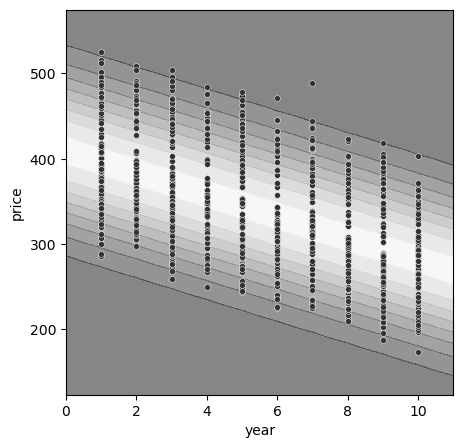

In [3]:
# 学習した線形回帰モデルの確率密度関数と学習データを重ねてプロット
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats

###### 確率密度関数を描画 ######
# (x,y)格子点を作成
x_min, x_max = np.min(x_train), np.max(x_train)
y_min, y_max = np.min(y_train), np.max(y_train)
x_grid = np.arange(x_min - 1, x_max + 2)
y_grid = np.linspace(y_min - 50, y_max + 50, num=200)
X, Y = np.meshgrid(x_grid, y_grid)
XY_grid = np.c_[X.ravel(), Y.ravel()]
# 確率密度関数
mu_grid = w_1 * XY_grid[:, 0] + w_0  # 線形予測子で平均μを予測
X_grid_pd = stats.norm.pdf(XY_grid[:, 1], loc=mu_grid, scale=np.sqrt(sigma2))
# 確率密度をプロット
X_grid_pivot = X_grid_pd.reshape(X.shape)  # ピボット化
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
ax.contourf(X, Y, X_grid_pivot, levels=10, cmap=cm.gray, alpha=0.5)

###### 学習データを散布図で描画 ######
sns.scatterplot(x=x_train, y=y_train,
                c='#333333', ax=ax, s=18, marker="o")
ax.set_xlabel('year')
ax.set_ylabel('price')
# グラフを表示
plt.show()

横軸に説明変数`year`、縦軸に応答変数`price`をとっています。データにフィットした確率密度関数が推定できていることがわかります。

## B. 推論

学習フェーズで求めたパラメータとしきい値を用いて、推論データに対する異常度の算出と異常判定を行います。

In [4]:
# コード7.8 線形回帰による1 説明変数の異常検知の実装例（推論）
###### 学習したパラメータをここに記載
W_1=-12.778952686336028 # 線形予測子の係数パラメータ
W_0=409.52848846804113 # 線形予測子の切片パラメータ
SIGMA2=3583.7515391302095 # 残差の分散パラメータσ^2
A_TH=4.916560173082554 # 異常度のしきい値

###### 推論データの読み込みと前処理######
# CSVからPandas DataFrameにデータ読み込み
df_inference = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/usedcar_dataset_inference.csv')
# 推論データの説明変数（'year'）と応答変数（'price'）をNumpyのndarray化
x_inference = df_inference['year'].to_numpy()
y_inference = df_inference['price'].to_numpy()

###### 推論を実行######
# 異常度を算出
anomaly_scores = (y_inference-W_1*x_inference-W_0)**2 / SIGMA2
# しきい値により異常の有無を判定
pred = np.where(anomaly_scores > A_TH, 'anomaly', 'normal')
# 推論結果を表示
print(pred)

['normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'norm

推論結果の決定境界（異常と正常の判定の境界）を可視化してみます。

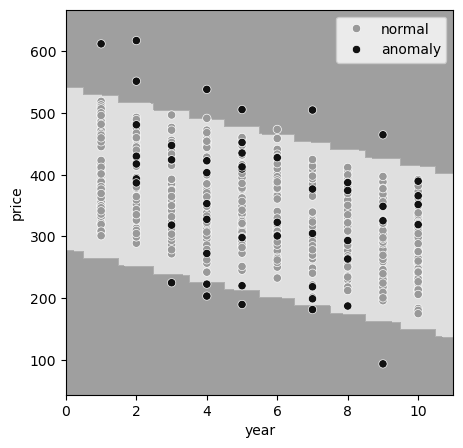

In [5]:
# 推論結果の決定境界を可視化
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

###### 正常と異常の範囲を色分け ######
# (x,y)格子点を作成
x_min, x_max = np.min(x_inference), np.max(x_inference)
y_min, y_max = np.min(y_inference), np.max(y_inference)
x_grid = np.arange(x_min-1, x_max+2)
y_grid = np.linspace(y_min-50, y_max+50, num=500)
X, Y = np.meshgrid(x_grid, y_grid)
XY_grid = np.c_[X.ravel(), Y.ravel()]
# 異常度を算出
anomaly_scores_grid = (XY_grid[:, 1]-W_1*XY_grid[:, 0]-W_0)**2 / SIGMA2
# しきい値判定
pred_grid = np.where(anomaly_scores_grid > A_TH, 0, 1)
# 正常と異常の境界をプロット
pred_pivot = pred_grid.reshape(X.shape)
ax.contourf(X, Y, pred_pivot, levels=1,
            cmap=cm.gray, alpha=0.5)

###### 各データを散布図としてプロット ######
sns.scatterplot(data=df_inference, x='year', y='price',
                hue='label', palette=['#999999', '#111111'], ax=ax)
# 凡例を追加
ax.legend()
# グラフを表示
plt.show()

図を見ると、正常範囲の中央に位置する異常データを多数検知できていない、すなわち見逃していることがわかります。これは、本来であれば車種（`model_name`）ごとに正常範囲が異なるにもかかわらず、車種を区別せずに一つのモデルで扱ったためです。このような車種による正常範囲の変化を考慮するためには、説明変数に`model_name`を追加して、車種ごとの正常範囲の違いをモデルに反映する必要があります。このような複数の説明変数を持つ線形回帰モデルによる異常検知の実装は、7.4節であらためて解説します。